# 1. Setup

In [1]:
!pip install google-adk

In [1]:
from IPython.display import HTML, Markdown, display

In [2]:
from google.colab import userdata
api_key = userdata.get('GOOGLE_API_KEY')

In [3]:
import os
from google import genai
from google.genai import types
from google.adk.agents import LlmAgent
from google.adk.models.google_llm import Gemini
from google.adk.runners import InMemoryRunner, Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools import google_search, AgentTool, ToolContext
from google.adk.code_executors import BuiltInCodeExecutor

In [4]:
def show_python_code_and_result(response):
  # Helper function that prints the generated Python code and results from the code execution tool
  for i in range(len(response)):
    # Check if the response contains a valid function call result from the code executor
    if (
        (response[i].content.parts)
        and (response[i].content.parts[0])
        and (response[i].content.parts[0].function_response)
        and (response[i].content.parts[0].function_response.response)
    ):
      response_code = response[i].content.parts[0].function_response.response
      if "result" in response_code and response_code["result"] != "```":
        if "tool_code" in response_code["result"]:
          print(
              "Generated Python Code >> ",
              response_code["result"].replace("tool_code", ""),
          )
        else:
          print("Generated Python Response >> ", response_code["result"])

In [5]:
retry_config = types.HttpRetryOptions(
    attempts=5,  # Maximum retry attempts
    exp_base=7,  # Delay multiplier
    initial_delay=1,
    http_status_codes=[429, 500, 503, 504],  # Retry on these HTTP errors
)

In [6]:
# Set API key as environment variable
os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')

client = genai.Client(api_key=api_key)

for model in client.models.list():
  print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2

In [7]:
# Define helper functions that will be reused throughout the notebook
async def run_session(
    runner_instance: Runner,
    user_queries: list[str] | str = None,
    session_name: str = "default",
):
    print(f"\n ### Session: {session_name}")

    # Get app name from the Runner
    app_name = runner_instance.app_name

    # Attempt to create a new session or retrieve an existing one
    try:
        session = await session_service.create_session(
            app_name=app_name, user_id=USER_ID, session_id=session_name
        )
    except:
        session = await session_service.get_session(
            app_name=app_name, user_id=USER_ID, session_id=session_name
        )

    # Process queries if provided
    if user_queries:
        # Convert single query to list for uniform processing
        if type(user_queries) == str:
            user_queries = [user_queries]

        # Process each query in the list sequentially
        for query in user_queries:
            print(f"\nUser > {query}")

            # Convert the query string to the ADK Content format
            query = types.Content(role="user", parts=[types.Part(text=query)])

            # Stream the agent's response asynchronously
            async for event in runner_instance.run_async(
                user_id=USER_ID, session_id=session.id, new_message=query
            ):
                # Check if the event contains valid content
                if event.content and event.content.parts:
                    # Filter out empty or "None" responses before printing
                    if (
                        event.content.parts[0].text != "None"
                        and event.content.parts[0].text
                    ):
                        print(f"{MODEL_NAME} > ", event.content.parts[0].text)
    else:
        print("No queries!")


print("Helper functions defined.")

Helper functions defined.


# 2. Agent Sessions

In [8]:
# Importing ADK Components
from typing import Any, Dict
from google.adk.agents import Agent, LlmAgent
from google.adk.apps.app import App, EventsCompactionConfig
from google.adk.models.google_llm import Gemini
from google.adk.sessions import DatabaseSessionService
from google.adk.sessions import InMemorySessionService
from google.adk.runners import Runner
from google.adk.tools.tool_context import ToolContext
from google.genai import types

## 2.1) Session Management

At the most base level, Large Language Models are **inherently stateless**. Their awareness is confined to the information you provide in a single API call. This means an agent without proper context management will react to the current prompt without considering any previous history.

From a user perspective, if everytime the user has to tell about the problem or the query from the begining before getting any work done from the LLM, it will be a bad experience. This is what happens with just raw LLMs.

In ADK, you can use `Sessions` for **short term memory management** and `Memory` for **long term memory**.



---

**What is a Session?**

A session is a container for conversations.<br>
It encapsulates the conversation history in chronological manner and also records all tool interactions and responses for a **single, continuous conversation**.<br>
A session is tied to a user and an agent; it is not shared with other users. Similalry, a session history for agent is not shared with other agents.
<br>

---

In ADK, a **Session** is comprised of two key components `Events` and `State`:
1. `Session.Events`
  - While a session is a container for conversations, `Events` are the building blocks of a conversation.
  - Example of Events:
    - *User Input*: A message from the user(can be text, image, audio, or combinations, etc.)
    - *Agent Response*: The agent's response to user's query (generated using LLM and maybe tools if needed)
    - *Tool Call*: the agents' decision to use an external tool or API
    - *Tool Output*: The data returned from a tool call, which the agent uses to continue its reasoning.

2. `Session.State`
  - `session.state` is the Agent's scratchpad, where it stores and updates dynamic details needed during the conversation. It can be thought of as a global `{key, value}` pair storage which is available to all subagents and tools.

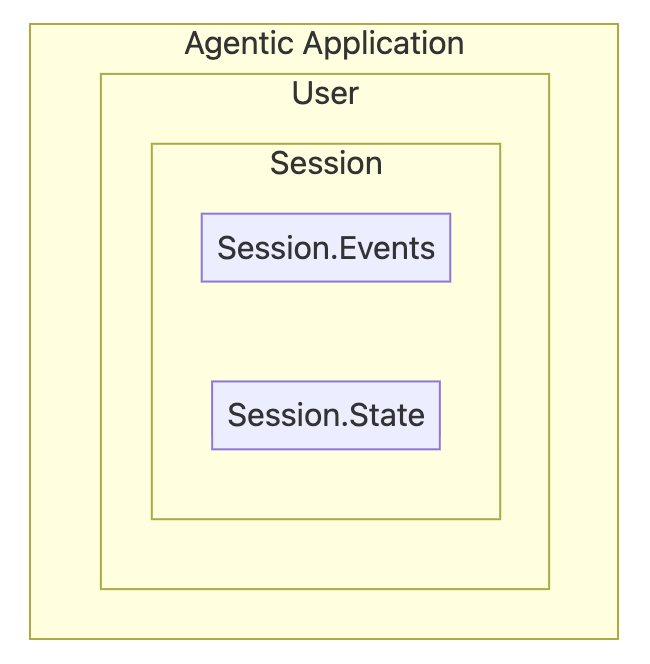

**How to manage Sessions?**

An agentic application can have multiple users and each user may have multiple sessions with the application. To manage these sessions and events, ADK offers a `Session Manager` and `Runner`.

1. `SessionService`: The storage layer
  - Manages creation, storage, and retrieval of session data
  - Different implementations for different needs (memory, database, cloud)

2. `Runner`: The orchestration layer
  - Manages the flow of information between user and agent
  - Automatically maintains conversation history
  - Handles the Context Engineering behind the scenes

Think of it like this:
  - Session = A notebook
  - Events = Individual entries in a single page
  - SessionService = The filing cabinet storing notebooks
  - Runner = The assistant managing the conversation

## 2.2) Implementing a Stateful Agent

first stateful agent, that can remember and have constructive conversations.

ADK offers different types of sessions suitable for different needs. As a start, we'll start with a simple Session Management option (`InMemorySessionService`)

In [9]:
APP_NAME = "default"  # Application
USER_ID = "default"  # User
SESSION = "default"  # Session

MODEL_NAME = "gemini-2.5-flash-lite"


# Create the LLM Agent
root_agent = Agent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="text_chat_bot",
    description="A text chatbot",  # Description of the agent's purpose
)

# Set up Session Management
# InMemorySessionService stores conversations in RAM (temporary)
session_service = InMemorySessionService()

# Create the Runner
runner = Runner(agent=root_agent, app_name=APP_NAME, session_service=session_service)

print("Stateful agent initialized!")
print(f"   - Application: {APP_NAME}")
print(f"   - User: {USER_ID}")
print(f"   - Using: {session_service.__class__.__name__}")

Stateful agent initialized!
   - Application: default
   - User: default
   - Using: InMemorySessionService


In [10]:
# Testing the agent with 2 queries in the same session
await run_session(
    runner,
    [
        "Hi, I am Vaibhav! What is the capital of United States?",
        "Hello! What is my name?",  # This time, the agent should remember as the query is part of the same session
    ],
    "stateful-agentic-session",
)


 ### Session: stateful-agentic-session

User > Hi, I am Vaibhav! What is the capital of United States?
gemini-2.5-flash-lite >  Hi Vaibhav! The capital of the United States is Washington, D.C.

User > Hello! What is my name?
gemini-2.5-flash-lite >  You told me your name is Vaibhav.


**`NOTE`**: Here the runner automatically maintained conversation history, but the catch is that `InMemorySessionService` is temporary; **Once the application stops, all conversation history is lost.**

In [11]:
# Run this cell after restarting the terminal session
# await run_session(
#     runner,
#     ["What did I ask you about earlier?", "And remind me, what's my name?"],
#     "stateful-agentic-session",
# )  # Note, we are using same session name

**`Problem`**: The session information is not persistent(i.e. meaningful conversations are lost). This is advantageous in testing env, however in real time, a user should be able to refer from past and resume conversations.

**`Solution`**: Persistent Information

## 2.3) Persistent Sessions with `DatabaseSessionService`

While `InMemorySessionService` is great for prototyping, real-world applications need conversations to survive restarts, crashes, and deployments.

ADK provides different SessionService implementations for different needs:


| Service | Use Case | Persistence |Best For|
| -------- | -------- | -------- | -------- |
| `InMemorySessionService` | Development & Testing | ❌ Lost on restart | Quick Prototypes |
| `DatabaseSessionService` | Self-managed apps | ✅ Survives restarts | Small to Medium Apps|
| Agent Engine Sessions | Production on GCP | ✅ Fully managed | Enterprise Scale |
<br>

---

**Implementing Persistent Sessions**

Using `DatabaseSessionService` using SQLite.(Gives persistence without needing a separate database server)

In [12]:
# Create agent (notice we use LlmAgent this time)
chatbot_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="text_chat_bot",
    description="A text chatbot with persistent memory",
)

# Switch to DatabaseSessionService
# SQLite database will be created automatically
db_url = "sqlite+aiosqlite:///my_agent_data.db"  # Local SQLite file, specifying aiosqlite for async support
session_service = DatabaseSessionService(db_url=db_url)

# Create a new runner with persistent storage
runner = Runner(agent=chatbot_agent, app_name=APP_NAME, session_service=session_service)

print("Upgraded to persistent sessions!")
print(f" - Database: my_agent_data.db")
print(f" - Sessions will survive restarts!")

Upgraded to persistent sessions!
 - Database: my_agent_data.db
 - Sessions will survive restarts!


**Test Run 1: Verifying Persistence**

In this first test run, we'll start a new conversation with the session ID `test-db-session-01`. We will first introduce our name as 'Vaibhav' and then ask a question. In the second turn, we will ask the agent for our name.

Since we are using `DatabaseSessionService`, the agent should remember the name.

After the conversation, we'll inspect the `my_agent_data.db` SQLite database directly to see how the conversation `events` (the user queries and model responses) are stored.

In [15]:
await run_session(
    runner,
    ["Hi, I am Vaibhav! What is the capital of the United States?", "Hello! What is my name?"],
    "test-db-session-01",
)


 ### Session: test-db-session-01

User > Hi, I am Vaibhav! What is the capital of the United States?
gemini-2.5-flash-lite >  Hi Vaibhav! The capital of the United States is Washington, D.C.

User > Hello! What is my name?
gemini-2.5-flash-lite >  Your name is Vaibhav.


In [13]:
# Run this after restarting your current session and not executing the prev cell
await run_session(
    runner,
    ["What is the capital of India?", "Hello! What is my name?"],
    "test-db-session-01",
)


 ### Session: test-db-session-01

User > What is the capital of India?
gemini-2.5-flash-lite >  The capital of India is New Delhi.

User > Hello! What is my name?
gemini-2.5-flash-lite >  Your name is Vaibhav.


In [14]:
# Since each session is a private conversation between user and agent
# Creating a news session to verify the claim
await run_session(
    runner, ["Hello! What is my name?"], "test-db-session-02"
)  # Note, we are using new session name


 ### Session: test-db-session-02

User > Hello! What is my name?
gemini-2.5-flash-lite >  I do not have access to your personal information, including your name. I am a text-based AI and do not store or recall user data.


In [17]:
# Checking how the events are stored in sqlite
import sqlite3

def check_data_in_db():
    with sqlite3.connect("my_agent_data.db") as connection:
        cursor = connection.cursor()
        result = cursor.execute(
            "select app_name, session_id, timestamp,event_data from events"
        )
        print([_[0] for _ in result.description])
        for each in result.fetchall():
            print(each)


check_data_in_db()

['app_name', 'session_id', 'timestamp', 'event_data']
('default', 'test-db-session-01', '2026-04-05 04:12:48.475718', '{"content": {"parts": [{"text": "Hi, I am Vaibhav! What is the capital of the United States?"}], "role": "user"}, "invocation_id": "e-6dadb732-c722-4717-aae3-b3b90886bc0b", "author": "user", "actions": {"state_delta": {}, "artifact_delta": {}, "requested_auth_configs": {}, "requested_tool_confirmations": {}}, "id": "dbd2420b-5cca-47f1-854b-370a80f82259", "timestamp": 1775362368.4757183}')
('default', 'test-db-session-01', '2026-04-05 04:12:48.504237', '{"model_version": "gemini-2.5-flash-lite", "content": {"parts": [{"text": "Hi Vaibhav! The capital of the United States is Washington, D.C."}], "role": "model"}, "finish_reason": "STOP", "usage_metadata": {"candidates_token_count": 17, "prompt_token_count": 47, "prompt_tokens_details": [{"modality": "TEXT", "token_count": 47}], "total_token_count": 64}, "invocation_id": "e-6dadb732-c722-4717-aae3-b3b90886bc0b", "author":

## 2.4) Context Compaction

As you can see, all the events are stored in full in the session Database, and this quickly adds up. For a long, complex task, this list of events can become very large, leading to slower performance and higher costs.

But what if we could automatically summarize the past? Using ADK's `Context Compaction` feature to see how to automatically reduce the context that's stored in the Session.

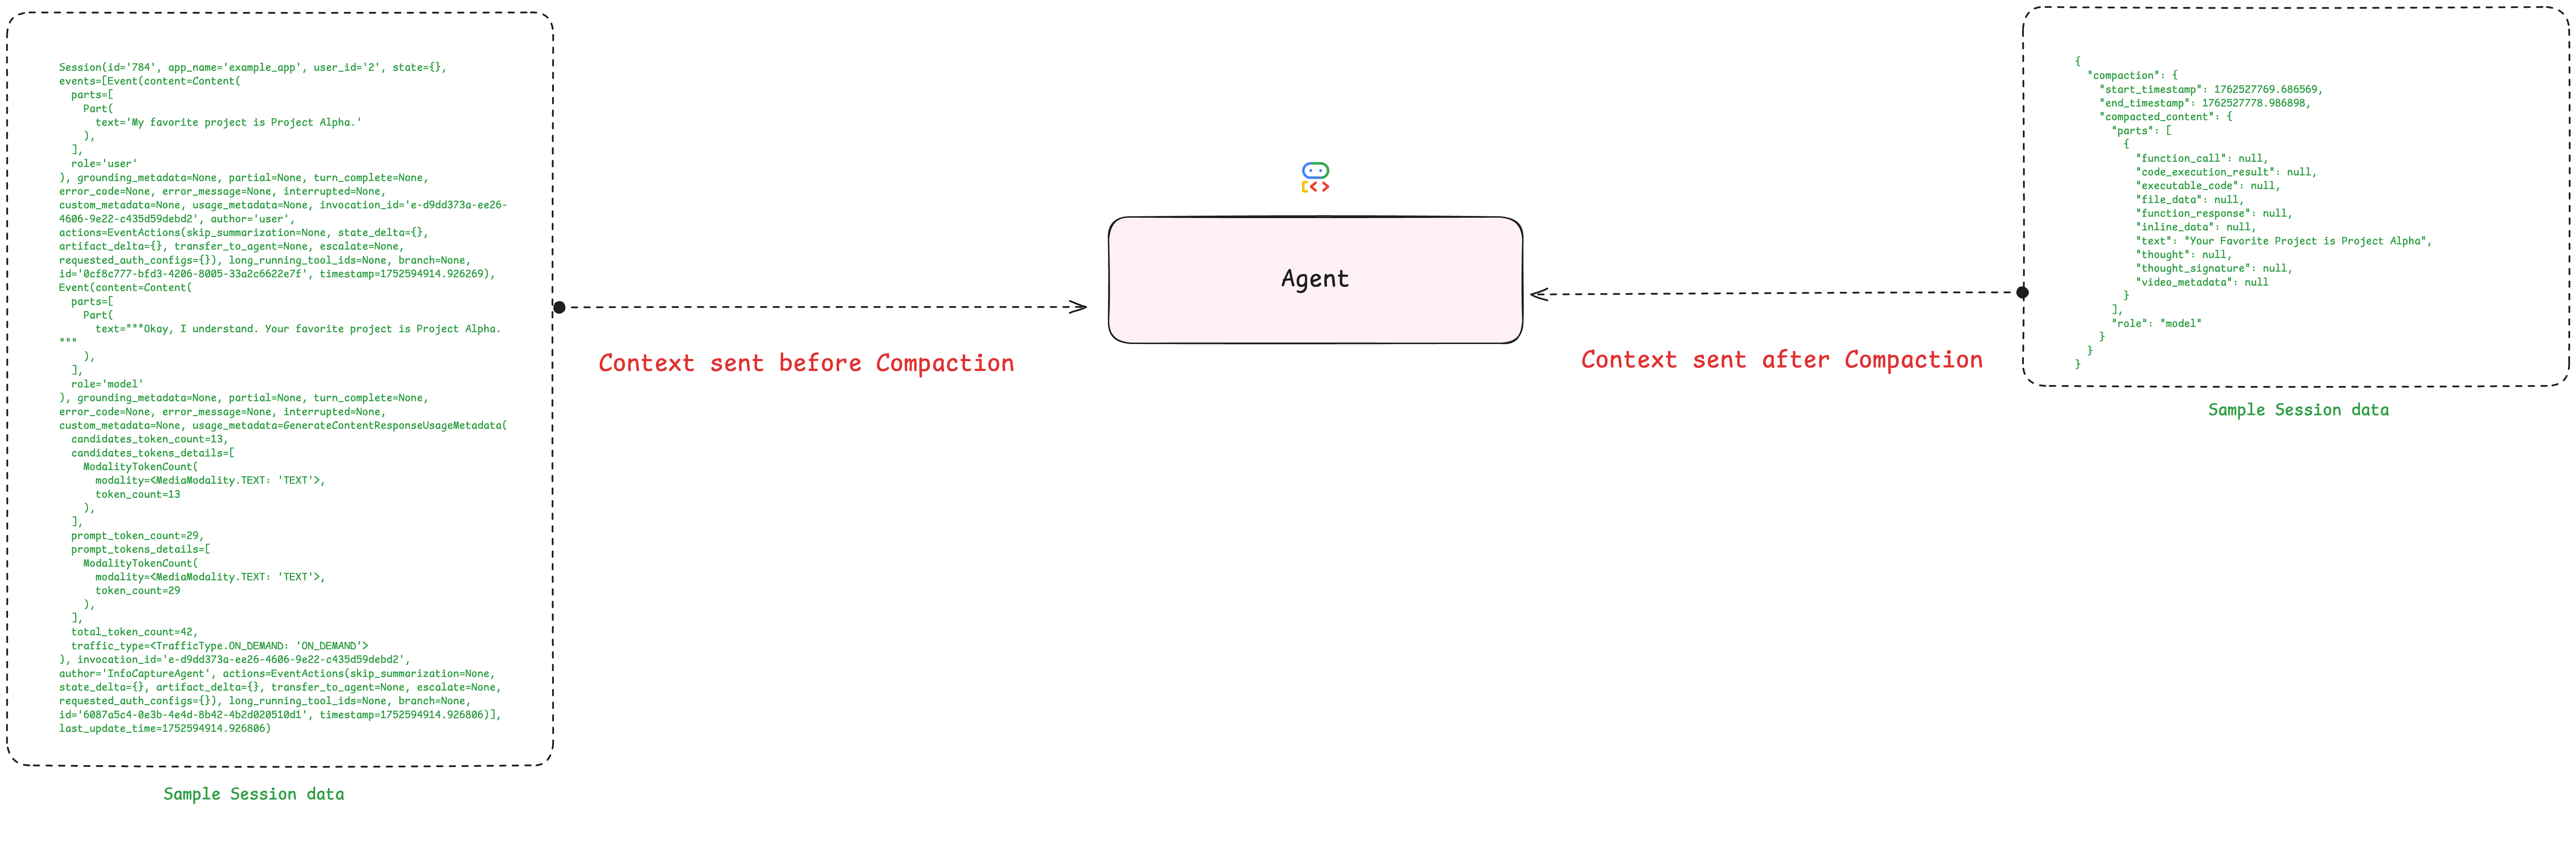

To use this wew will use the previous `chatbot_agent` from section 2.2.
Which creating the `App` object we alse create a new config to do the context compaction. This `EventsCompactConfig` defines to key variables:
  - `compaction_interval`: Asks the runner to compact the history after every `n` conversations
  - `overlap_size`: Defines the number of previous conversations to retain for overlap

In [19]:
# Re-define our app with Events Compaction enabled
research_app_compacting = App(
    name="research_app_compacting",
    root_agent=chatbot_agent,
    events_compaction_config=EventsCompactionConfig(
        compaction_interval=3,  # Trigger compaction every 3 invocations
        overlap_size=1,  # Keep 1 previous turn for context
    ),
)

db_url = "sqlite+aiosqlite:///my_agent_data.db"  # Local SQLite file, specifying aiosqlite for async support
session_service = DatabaseSessionService(db_url=db_url)

# Create a new runner for upgraded app
research_runner_compacting = Runner(
    app=research_app_compacting, session_service=session_service
)

print("Research App upgraded with Events Compaction!")

Research App upgraded with Events Compaction!


/tmp/ipykernel_50355/1197531748.py:5: UserWarning: [EXPERIMENTAL] EventsCompactionConfig: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  events_compaction_config=EventsCompactionConfig(


In [20]:
# Turn 1
await run_session(
    research_runner_compacting,
    "What is the latest news about AI in healthcare?",
    "compaction_demo",
)

# Turn 2
await run_session(
    research_runner_compacting,
    "Are there any new developments in drug discovery?",
    "compaction_demo",
)

# Turn 3 - Compaction should trigger after this turn
await run_session(
    research_runner_compacting,
    "Tell me more about the second development you found.",
    "compaction_demo",
)

# Turn 4
await run_session(
    research_runner_compacting,
    "Who are the main companies involved in that?",
    "compaction_demo",
)


 ### Session: compaction_demo

User > What is the latest news about AI in healthcare?
gemini-2.5-flash-lite >  Here's a summary of the latest news and trends in AI in healthcare, covering a few key areas:

**1. Drug Discovery and Development:**

*   **Accelerated Drug Discovery:** AI is making significant strides in identifying potential drug candidates and predicting their efficacy. Companies are using AI to analyze vast datasets of biological information, protein structures, and molecular interactions, drastically shortening the time and cost of early-stage drug discovery.
*   **Personalized Medicine:** AI is enabling the development of more personalized treatments by analyzing a patient's genetic makeup, lifestyle, and medical history to predict their response to specific drugs and tailor treatment plans.
*   **Clinical Trial Optimization:** AI is being used to improve the design and execution of clinical trials, including patient selection, site selection, and data analysis, makin

**Verifying Compaction in the Session History**

The above conversation has been compacted but looks normal, so lets inspect the `events` list from the session. The compaction process **doesn't delete old events; it replaces them with a single, new `Event` that contains the summary**.

In [21]:
# Get the final session state
final_session = await session_service.get_session(
    app_name=research_runner_compacting.app_name,
    user_id=USER_ID,
    session_id="compaction_demo",
)

print("--- Searching for Compaction Summary Event ---")
found_summary = False
for event in final_session.events:
    # Compaction events have a 'compaction' attribute
    if event.actions and event.actions.compaction:
        print("\nSUCCESS! Found the Compaction Event:")
        print(f"  Author: {event.author}")
        print(f"\n Compacted information: {event}")
        found_summary = True
        break

if not found_summary:
    print(
        "\nNo compaction event found. Try increasing the number of turns in the demo."
    )

--- Searching for Compaction Summary Event ---

SUCCESS! Found the Compaction Event:
  Author: user

 Compacted information: model_version=None content=None grounding_metadata=None partial=None turn_complete=None finish_reason=None error_code=None error_message=None interrupted=None custom_metadata=None usage_metadata=None live_session_resumption_update=None input_transcription=None output_transcription=None avg_logprobs=None logprobs_result=None cache_metadata=None citation_metadata=None interaction_id=None invocation_id='c2375731-6e54-4614-b809-2e7283f5b08e' author='user' actions=EventActions(skip_summarization=None, state_delta={}, artifact_delta={}, transfer_to_agent=None, escalate=None, requested_auth_configs={}, requested_tool_confirmations={}, compaction=EventCompaction(start_timestamp=1775363237.159833, end_timestamp=1775363243.2161999, compacted_content=Content(
  parts=[
    Part(
      text="""The conversation began with a user asking for the latest news on AI in healthcare.

The presence of that special summary Event in session's history is the tangible result of the compaction process.

Recap of all points:
1. `Silent Operation`: You ran a standard conversation, and from the outside, nothing seemed different.
2. `Background Compaction`: Because you configured the `App` with `EventsCompactionConfig`, the ADK `Runner` automatically monitored the conversation length. Once the threshold was met, it triggered the summarization process in the background.
3. Verified Result: By inspecting the session's events, you found the summary that the LLM generated. This summary now replaces the older, more verbose turns in the agent's active context.

**For all future turns in this conversation, the agent will be given this concise summary instead of the full history**
. This saves costs, improves performance, and helps the agent stay focused on what's most important.



---


**Custom Compaction**
- By defining a custom `SlidingWindowCompactor` and passing it to config; it allows you to control the summarization prompt or even use a different, specialized LLM for the task.<br>

Refer: <a href="https://adk.dev/context/compaction/">Context Compaction</a>


---


**Context Caching**
- When working with agents to complete tasks, you may want to reuse extended instructions or large sets of data across multiple agent requests to a generative AI model. Resending this data for each agent request is slow, inefficient, and can be expensive. Using context caching features in generative AI models can significantly speed up responses and lower the number of tokens sent to the model for each request.
- The `ContextCacheConfig` class has the following settings that control how caching works for your agent. When you configure these settings, they apply to all agents within your app.
  - `min_tokens` (int): The minimum number of tokens required in a request to enable caching. This setting allows you to avoid the overhead of caching for very small requests where the performance benefit would be negligible. Defaults to 0.
  - `ttl_seconds` (int): The time-to-live (TTL) for the cache in seconds. This setting determines how long the cached content is stored before it is refreshed. Defaults to `1800` (30 minutes).
  - `cache_intervals` (int): The maximum number of times the same cached content can be used before it expires. This setting allows you to control how frequently the cache is updated, even if the TTL has not expired. Defaults to `10`.

Refer: <A href="https://adk.dev/context/caching/">Context Caching</a>

## 2.5) Working with Session State

While we can do Context Compaction and use a database to resume a session, **we face new challenges now. In some cases, we have key information or preferences that we want to share across other sessions.**

In these scenarios, instead of sharing the entire session history, transferring information from a few key variables can improve the session experience.



---

**Creating Custom Tools for Session State Management**

We can manually manage session state through custom tools. In this example, we'll identify a *transferable characteristic*, like a user's name and their country, and create tools to capture and save it.

Why This Example?

The username is a perfect example of information that:
- Is introduced once but referenced multiple times
- Should persist throughout a conversation
- Represents a user-specific characteristic that enhances personalization

Here, for demo purposes, we'll create two tools that can store and retrieve user name and country from the Session State.

`Note that all tools have access to the ToolContext object.`
You don't have to create separate tools for each piece of information you want to share.

In [22]:
# Define scope levels for state keys (following best practices)
USER_NAME_SCOPE_LEVELS = ("temp", "user", "app")

# This demonstrates how tools can write to session state using tool_context.
# The 'user:' prefix indicates this is user-specific data.
def save_userinfo(tool_context: ToolContext, user_name: str, country: str) -> Dict[str, Any]:
    """
    Tool to record and save user name and country in session state.

    Args:
        user_name: The username to store in session state
        country: The name of the user's country
    """
    # Write to session state using the 'user:' prefix for user data
    tool_context.state["user:name"] = user_name
    tool_context.state["user:country"] = country

    return {"status": "success"}

# This demonstrates how tools can read from session state.
def retrieve_userinfo(tool_context: ToolContext) -> Dict[str, Any]:
    """
    Tool to retrieve user name and country from session state.
    """
    # Read from session state
    user_name = tool_context.state.get("user:name", "Username not found")
    country = tool_context.state.get("user:country", "Country not found")

    return {"status": "success", "user_name": user_name, "country": country}

print("Tools created.")

Tools created.


Key Concepts:
- Tools can access tool_context.state to read/write session state
- Use descriptive key prefixes (user:, app:, temp:) for organization
- State persists across conversation turns within the same session

In [23]:
# Creating an agent with session state tools
# Configuration
APP_NAME = "default"
USER_ID = "default"
MODEL_NAME = "gemini-2.5-flash-lite"

# Create an agent with session state tools
root_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="text_chat_bot",
    description="""A text chatbot.
    Tools for managing user context:
    * To record username and country when provided use `save_userinfo` tool.
    * To fetch username and country when required use `retrieve_userinfo` tool.
    """,
    tools=[save_userinfo, retrieve_userinfo],  # Provide the tools to the agent
)

# Set up session service and runner
session_service = InMemorySessionService()
runner = Runner(agent=root_agent, session_service=session_service, app_name="default")

print("Agent with session state tools initialized!")

Agent with session state tools initialized!


In [25]:
# Test conversation demonstrating session state
await run_session(
    runner,
    [
        "Hi there, how are you doing today? What is my name?",  # Agent shouldn't know the name yet
        "My name is Vaibhav. I'm from India.",  # Provide name - agent should save it
        "What is my name? Which country am I from?",  # Agent should recall from session state
    ],
    "state-demo-session",
)


 ### Session: state-demo-session

User > Hi there, how are you doing today? What is my name?
gemini-2.5-flash-lite >  Hello! I'm doing great, thank you for asking. I can't remember your name right now. Would you like to tell me what it is? 


User > My name is Vaibhav. I'm from India.
gemini-2.5-flash-lite >  It's nice to meet you, Vaibhav! I'll remember that you're from India.

User > What is my name? Which country am I from?
gemini-2.5-flash-lite >  Your name is Vaibhav and you are from India.


In [26]:
# Inspecting Session State
# Retrieve the session and inspect its state
session = await session_service.get_session(
    app_name=APP_NAME, user_id=USER_ID, session_id="state-demo-session"
)

print("Session State Contents:")
print(session.state)
print("\nNotice the 'user:name' and 'user:country' keys storing our data!")

Session State Contents:
{'user:name': 'Vaibhav', 'user:country': 'India'}

Notice the 'user:name' and 'user:country' keys storing our data!


**Session State Isolation**

As we've already seen, an important characteristic of session state is that it's isolated per session.

In [27]:
# Start a completely new session - the agent won't know our name
await run_session(
    runner,
    ["Hi there, how are you doing today? What is my name?"],
    "new-isolated-session",
)

# Expected: The agent won't know the name because this is a different session


 ### Session: new-isolated-session

User > Hi there, how are you doing today? What is my name?
gemini-2.5-flash-lite >  Hello! I'm doing great. To protect your privacy, I don't store any personal information unless you explicitly tell me to. So, I don't know your name.



**Cross-Session State Sharing**

In [28]:
# Check the state of the new session
session = await session_service.get_session(app_name=APP_NAME,
                                            user_id=USER_ID,
                                            session_id="new-isolated-session")

print("New Session State:")
print(session.state)

# Note: Depending on implementation, you might see shared state here.
# This is where the distinction between session-specific and user-specific state becomes important.

New Session State:
{'user:name': 'Vaibhav', 'user:country': 'India'}


In [29]:
# Clean up any existing database to start fresh (if Notebook is restarted)
import os

if os.path.exists("my_agent_data.db"):
    os.remove("my_agent_data.db")
print("Cleaned up old database files")

Cleaned up old database files


# 3. Agent Memory and Memory Management

In [30]:
from google.adk.agents import LlmAgent
from google.adk.models.google_llm import Gemini
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.adk.memory import InMemoryMemoryService
from google.adk.tools import load_memory, preload_memory
from google.genai import types

In this section we add **Memory**- a searchable, long-term knowledge store that persists across multiple conversations.


---

**What is Memory?**

Memory is a service that provides long-term knowledge storage for your agents.
The key distinction:
- **Session = Short-term memory** (Single Conversation)
- **Memory = Long-term knowledge** (across multiple conversations)


---

**Why Memory?**

Memory provides capabilities that sessions alone cannot:


| Capability | What It Means | Example |
|----------|----------|----------|
| Cross-Conversation Recall | Access information from any past conversation | "What preferences has this user mentioned across all chats?" |
| Intelligent Extraction | LLM-powered consolidation extracts key facts | Stores "allergic to peanuts" instead of 50 raw messages |
| Semantic Search | Meaning-based retrieval, not just keyword matching | Query "preferred hue" matches "favorite color is blue" |
| Persistent Storage | Survives application restarts | Build knowledge that grows over time |

## 3.1) Memory Workflow

In order to integrate Memory into your Agents, there are **three high-level steps**.

Three-step integration process:
1. `Initialize`-> Create a `MemoryService` and provide it to your agent via the `Runner`.
2. `Ingest`-> Transfer session data to memory using `add_session_to_memory()`.
3. `Retrieve`-> Search store memories using `search_memory()`

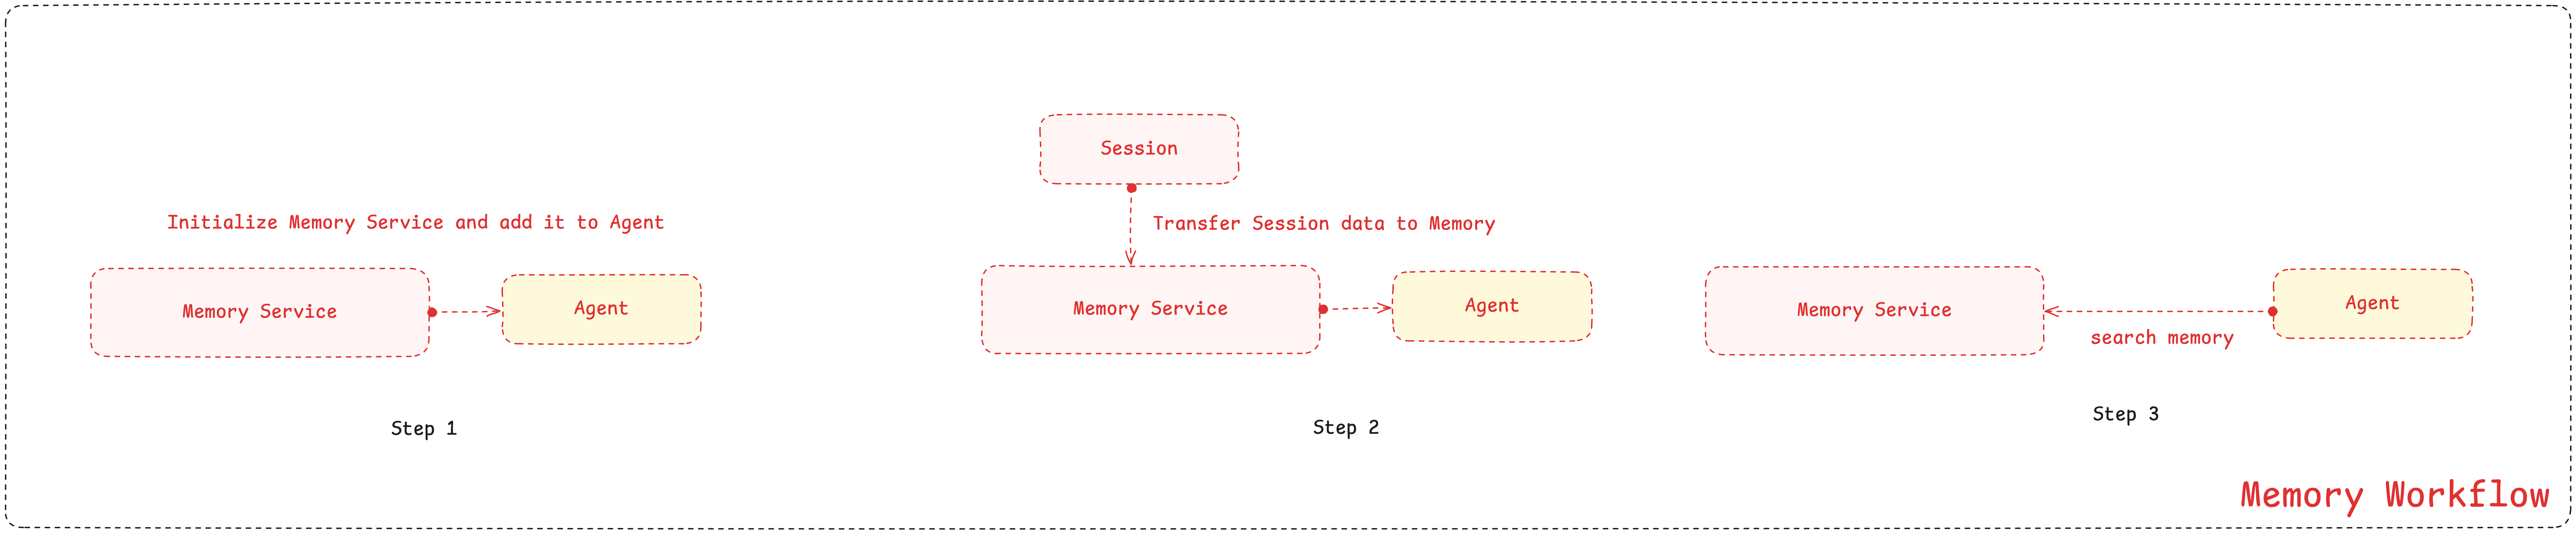

## 3.2) Initializing MemoryService

ADK provides multiple `MemoryService` implementations through the `BaseMemoryService` interface:

- `InMemoryMemoryService` - Built-in service for prototyping and testing (keyword matching, no persistence)
- `VertexAiMemoryBankService` - Managed cloud service with LLM-powered consolidation and semantic search
- `Custom implementations` - You can build your own using databases, though managed services are recommended

We can use `InMemoryMemoryService` to learn the core mechanics. The same methods work identically with production-ready services like Vertex AI Memory Bank.

In [31]:
memory_service = (
    InMemoryMemoryService()
)  # ADK's built-in Memory Service for development and testing

In [32]:
# Adding the memory to agent
# Define constants used throughout the notebook
APP_NAME = "MemoryDemoApp"
USER_ID = "demo_user"

# Create agent
user_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="MemoryDemoAgent",
    instruction="Answer user questions in simple words.",
)

print("Agent created")

Agent created


Now provide both Session and Memory services to the `Runner`.

Key configuration:

The `Runner` requires both services to enable memory functionality:
- `session_service` → Manages conversation threads and events
- `memory_service` → Provides long-term knowledge storage

Both services work together: Sessions capture conversations, Memory stores knowledge for retrieval across sessions.

In [33]:
# Create Session Service
session_service = InMemorySessionService()  # Handles conversations

# Create runner with BOTH services
runner = Runner(
    agent=user_agent,
    app_name="MemoryDemoApp",
    session_service=session_service,
    memory_service=memory_service,  # Memory service is now available
)

print("Agent and Runner created with memory support!")

Agent and Runner created with memory support!


**`Configuration V/S Usage`**

Adding `memory_service` to the `Runner` makes memory *available* to your agent, but doesn't automatically use it. You must explicitly:
1. **Ingest data** using `add_session_to_memory()`.
2. **Enable retrieval** by giving your agent memory tools (`load_memory` or `preload_memory`)


---

**MemoryService Implementation Options**
For this notebook: `InMemoryMemoryService`
- Stores raw conversation events without consolidation
- Keyword-based search (simple word matching)
- In-memory storage (resets on restart)
- Ideal for learning and local development

**Production: `VertexAiMemoryBankService`**
- LLM-powered extraction of key facts
- Semantic search (meaning-based retrieval)
- Persistent cloud storage
- Integrates external knowledge sources

**API Consistency**: Both implementations use identical methods (`add_session_to_memory()`, `search_memory()`).

## 3.3) Ingest Session Data into Memory

**Why should you transfer Session data to Memory?**

Now that memory is initialized, you need to populate it with knowledge. When you initialize a MemoryService, it starts completely empty. All your conversations are stored in Sessions, which contain raw events including every message, tool call, and metadata. To make this information available for long-term recall, you explicitly transfer it to memory using `add_session_to_memory()`.

Here's where managed memory services like Vertex AI Memory Bank shine. **During transfer, they perform intelligent consolidation - extracting key facts while discarding conversational noise**. The `InMemoryMemoryService` we're using stores everything without consolidation, which is sufficient for learning the mechanics.

Before we can transfer anything, we need data. Let's have a conversation with our agent to populate the session. This conversation will be stored in the SessionService.

In [34]:
# User tells agent about their favorite color
await run_session(
    runner,
    "My favorite color is blue-green. Can you write a Haiku about it?",
    "conversation-01",  # Session ID
)


 ### Session: conversation-01

User > My favorite color is blue-green. Can you write a Haiku about it?
gemini-2.5-flash-lite >  A lovely blue-green,
Ocean's depth and forest's shade,
Calming, peaceful hue.


In [35]:
# Lets verify the conversation was captured in the session.
session = await session_service.get_session(
    app_name=APP_NAME, user_id=USER_ID, session_id="conversation-01"
)

print("Session contains:")
for event in session.events:
    text = (event.content.parts[0].text[:60]
        if event.content and event.content.parts
        else "(empty)")

    print(f"  {event.content.role}: {text}")

Session contains:
  user: My favorite color is blue-green. Can you write a Haiku about
  model: A lovely blue-green,
Ocean's depth and forest's shade,
Calmi


Perfect! The session contains our conversation. Now we're ready to transfer it to memory. Call `add_session_to_memory()` and pass the session object. This ingests the conversation into the memory store, making it available for future searches.

In [36]:
await memory_service.add_session_to_memory(session)

print("Session added to memory")

Session added to memory


## 3.4) Enabling Memory Retrival in Agent

We've successfully transferred session data to memory, but there is one crucial step remaining. **Agents can't directly access the MemoryService - they need tools to search it**.

This is done by design: it gives you control over when and how memory is retrieved.



---

**Memory Retrieval in ADK**
ADK provides two built-in tools for memory retrieval:

- `load_memory` **(Reactive)**
  - Agent decides when to search memory
  - Only retrieves when the agent thinks it's needed
  - More efficient (saves tokens)
  - Risk: Agent might forget to search

- `preload_memory` **(Proactive)**
  - Automatically searches before every turn
  - Memory always available to the agent
  - Guaranteed context, but less efficient
  - Searches even when not needed

Think of it like studying for an exam: `load_memory` is looking things up only when you need them, while `preload_memory` is reading all your notes before answering each question.

In [37]:
# Adding LoadMemory Tool to Agent (Implementing Reactive Pattern)
# Since `load_memory` is a built-in ADK tool, we include it directly without implementation

# Create agent
user_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="MemoryDemoAgent",
    instruction="Answer user questions in simple words. Use load_memory tool if you need to recall past conversations.",
    tools=[load_memory],  # Agent now has access to Memory and can search it whenever it decides to
)

print("Agent with load_memory tool created.")

Agent with load_memory tool created.


In [38]:
# Updating the runner and test
# Since sessions don't share conversation history, the only way the agent can
# answer correctly is by using the load_memory tool to retrieve the information
# from long-term memory that we manually stored.

# Create a new runner with the updated agent
runner = Runner(
    agent=user_agent,
    app_name=APP_NAME,
    session_service=session_service,
    memory_service=memory_service,
)

await run_session(runner, "What is my favorite color?", "color-test")


 ### Session: color-test

User > What is my favorite color?
gemini-2.5-flash-lite >  It is blue-green.


**Complete Manual Workflow Test**

The full cycle goes as: **ingest -> store -> retrieve**.

In [39]:
await run_session(runner, "My birthday is on May 25th.", "birthday-session-01")


 ### Session: birthday-session-01

User > My birthday is on May 25th.
gemini-2.5-flash-lite >  Ok, I will remember that.


Now manually save this session to memory. This is the crucial step that transfers the conversation from short-term session storage to long-term memory storage.

In [40]:
# Manually save the session to memory
birthday_session = await session_service.get_session(app_name=APP_NAME,
                                                     user_id=USER_ID,
                                                     session_id="birthday-session-01")

await memory_service.add_session_to_memory(birthday_session)

print("Birthday session saved to memory")

Birthday session saved to memory


In [41]:
# Test retrieval in a NEW session
await run_session(runner,
                  "When is my birthday?",
                  "birthday-session-02"  # Different session ID
                  )


 ### Session: birthday-session-02

User > When is my birthday?
gemini-2.5-flash-lite >  Your birthday is on May 25th.


What happens:
1. Agent receives: "When is my birthday?"
2. Agent recognizes: This requires past conversation context
3. Agent calls: `load_memory("birthday")`
4. Memory returns: Previous conversation containing "May 25th"
5. Agent responds: "Your birthday is on May 25th"

The memory retrieval worked even though this is a completely different session

In [42]:
# Update the agent to use preload_memory instead of load_memory
user_agent_proactive = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="MemoryDemoAgentProactive",
    instruction="Answer user questions in simple words.",
    tools=[preload_memory],  # Automatically loads memory before every turn
)

# Create a new runner with the updated agent
runner_proactive = Runner(
    agent=user_agent_proactive,
    app_name=APP_NAME,
    session_service=session_service,
    memory_service=memory_service,
)

print("--- Testing preload_memory with a relevant question ---")
await run_session(
    runner_proactive,
    "What is my favorite color?",
    "preload-session-01"
)

print("\n--- Testing preload_memory with an irrelevant question ---")
await run_session(
    runner_proactive,
    "Tell me a joke", # still searches memory even though it's unnecessary
    "preload-session-02"
)

--- Testing preload_memory with a relevant question ---

 ### Session: preload-session-01

User > What is my favorite color?
gemini-2.5-flash-lite >  Your favorite color is blue-green.

--- Testing preload_memory with an irrelevant question ---

 ### Session: preload-session-02

User > Tell me a joke
gemini-2.5-flash-lite >  Why don't scientists trust atoms?

Because they make up everything!


**Manual Memory Search**
Beyond agent tools, you can also search memories directly in your code. This is useful for:
- Debugging memory contents
- Building analytics dashboards
- Creating custom memory management UIs
The `search_memory()` method takes a text query and returns a `SearchMemoryResponse` with matching memories.

In [45]:
# Search for color preferences
search_response = await memory_service.search_memory(app_name=APP_NAME,
                                                     user_id=USER_ID,
                                                     query="What is the user's favorite color?"
                                                     )
# Query Options: "What color does user like?", "haiku", "age", "preferred hue"

print("Search Results:")
print(f"  Found {len(search_response.memories)} relevant memories")
print()

for memory in search_response.memories:
    if memory.content and memory.content.parts:
        text = memory.content.parts[0].text[:80]
        print(f"[{memory.author}]: {text}")

Search Results:
  Found 3 relevant memories

[user]: My favorite color is blue-green. Can you write a Haiku about it?
[MemoryDemoAgent]: A lovely blue-green,
Ocean's depth and forest's shade,
Calming, peaceful hue.
[user]: My birthday is on May 25th.


Memory search is grounded in reality - agents can't hallucinate memories that don't exist.


---

**How Search Works**
`InMemoryMemoryService`:
- Method: Keyword matching
- Example: "favorite color" matches because those exact words exist
- Limitation: "preferred hue" won't match

`VertexAiMemoryBankService`:
- Method: Semantic search via embeddings
- Example: "preferred hue" WILL match "favorite color"
- Advantage: Understands meaning, not just keywords

## 3.5) Automating Memory Storage

So far, we've manually called `add_session_to_memory()` to transfer data to long-term storage. Production systems need this to happen *automatically*.

**Callbacks**
ADK's callback system lets you hook into key execution moments. Callbacks are *Python functions* you define and attach to agents - ADK automatically calls them at specific stages, acting like checkpoints during the agent's execution flow.

**Think of callbacks as event listeners in your agent's lifecycle**. When an agent processes a request, it goes through multiple stages: receiving the input, calling the LLM, invoking tools, and generating the response.
<br>`Callbacks let you insert custom logic at each of these stages without modifying the core agent code.`
<br>

**Available callback types**:
- `before_agent_callback` → Runs before agent starts processing a request
- `after_agent_callback` → Runs after agent completes its turn
- `before_tool_callback` / `after_tool_callback` → Around tool invocations
- `before_model_callback` / `after_model_callback` → Around LLM calls
- `on_model_error_callback` → When errors occur

**Common use cases**:
- Logging and observability (track what the agent does)
- Automatic data persistence (like saving to memory)
- Custom validation or filtering
- Performance monitoring

Refer: <a href="https://adk.dev/callbacks/">ADK Callbacks Documentation</a>

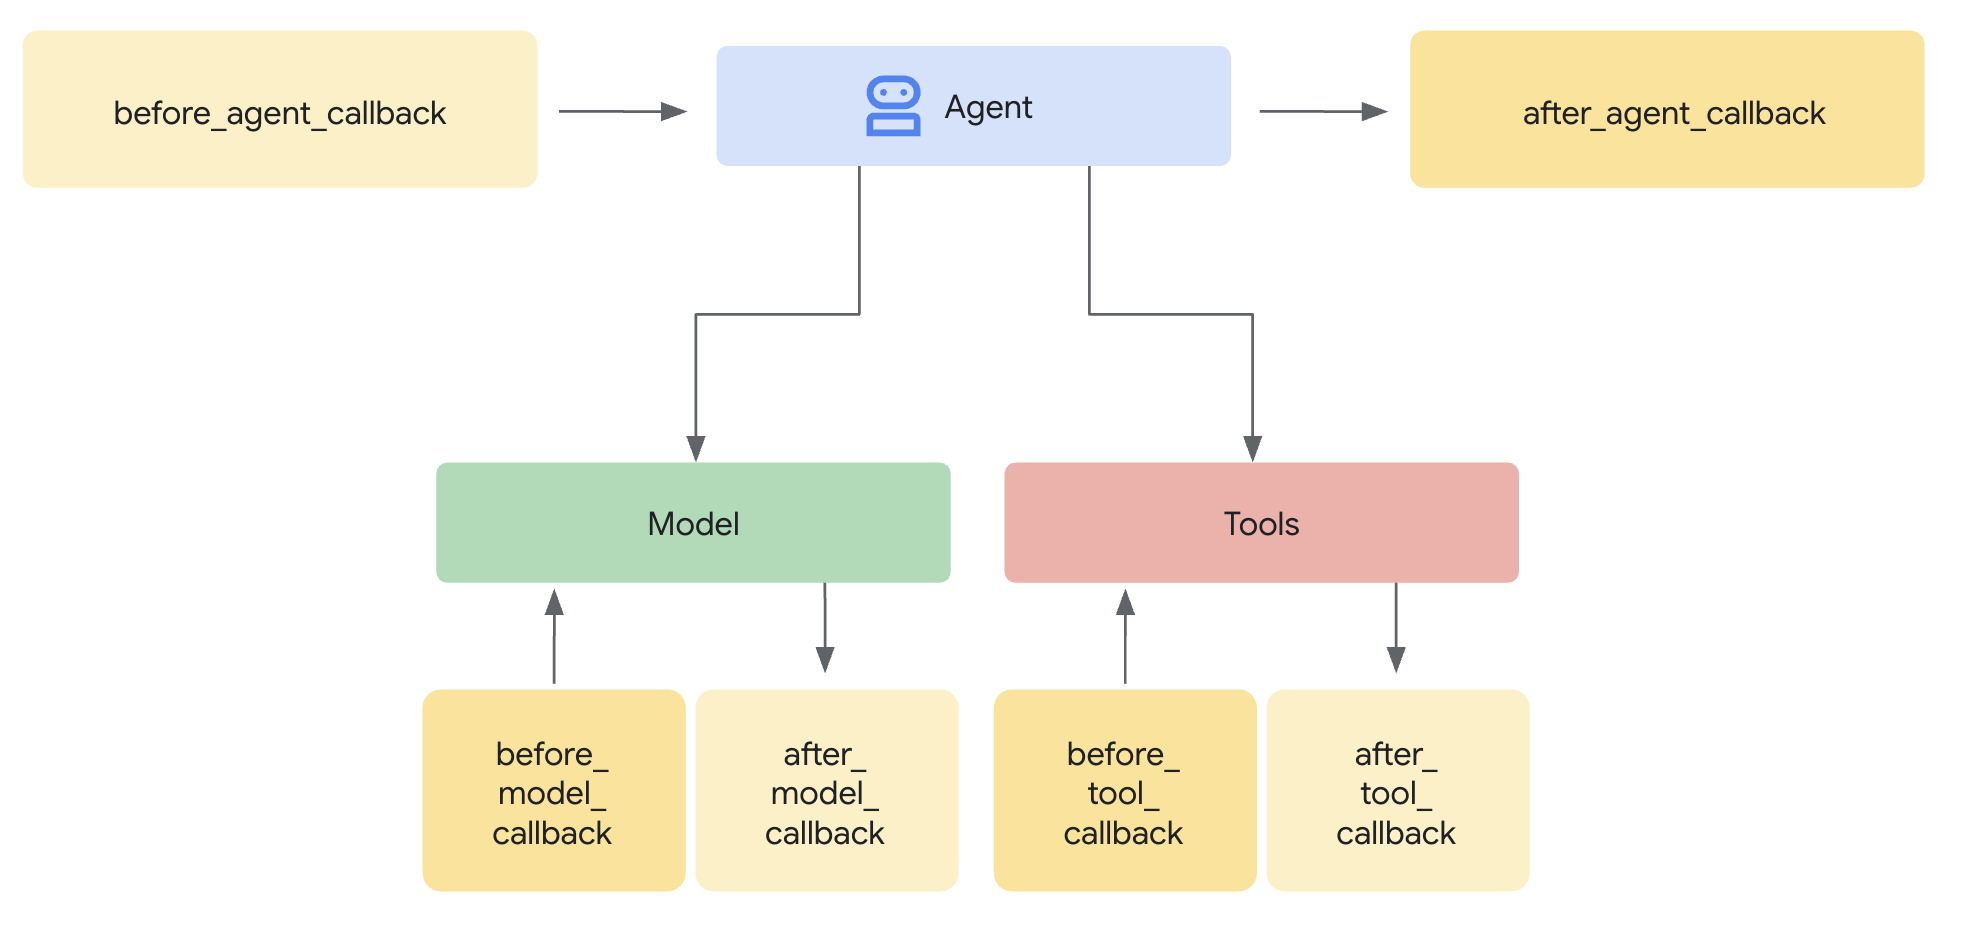

### 3.5.1) Automatic Memory Storage with Callbacks

For automatic memory storage, we'll use `after_agent_callback`. This function triggers every time the agent finishes a turn, then calls `add_session_to_memory()` to persist the conversation automatically.

But here's the challenge: how does our callback function actually access the memory service and current session? That's where `callback_context` comes in.

When you define a callback function, ADK automatically passes a special parameter called `callback_context` to it. The `callback_context` provides access to the Memory Service and other runtime components.

In our callback, we'll access the memory service and current session to automatically save conversation data after each turn.

`Important: You don't create this context - ADK creates it and passes it to your callback automatically when the callback runs.`

In [46]:
async def auto_save_to_memory(callback_context):
    """Automatically save session to memory after each agent turn."""
    await callback_context._invocation_context.memory_service.add_session_to_memory(callback_context._invocation_context.session)

print("Callback created.")

Callback created.


### 3.5.2) Creating an Agent: Callback adn PreLoad Memory Tool

An agent that combines:
- **Automatic Storage**: `after_agent_callback` saves conversations
- **Automatic Retrieval**: `preload_memory` loads memories

This creates a fully automated memory system with zero manual intervention.

In [47]:
# Agent with automatic memory saving
auto_memory_agent = LlmAgent(
    model=Gemini(model="gemini-2.5-flash-lite", retry_options=retry_config),
    name="AutoMemoryAgent",
    instruction="Answer user questions.",
    tools=[preload_memory],
    after_agent_callback=auto_save_to_memory,  # Saves after each turn
)

print("Agent created with automatic memory saving!")

Agent created with automatic memory saving!


What happens automatically:

- After every agent response → callback triggers
- Session data → transferred to memory
- No manual `add_session_to_memory()` calls needed

### 3.5.3) Creating a Runner and testing the agent

In [48]:
# Create a runner for the auto-save agent
# This connects our automated agent to the session and memory services
auto_runner = Runner(agent=auto_memory_agent,  # Use the agent with callback + preload_memory
    app_name=APP_NAME,
    session_service=session_service,  # Same services from previous section
    memory_service=memory_service,
)

print("Runner created.")

Runner created.


In [49]:
# Test 1: Tell the agent about a gift (first conversation)
# The callback will automatically save this to memory when the turn completes
await run_session(
    auto_runner,
    "I gifted a new toy to my nephew on his 1st birthday!",
    "auto-save-test",
)

# Test 2: Ask about the gift in a NEW session (second conversation)
# The agent should retrieve the memory using preload_memory and answer correctly
await run_session(
    auto_runner,
    "What did I gift my nephew?",
    "auto-save-test-2",  # Different session ID - proves memory works across sessions!
)


 ### Session: auto-save-test

User > I gifted a new toy to my nephew on his 1st birthday!
gemini-2.5-flash-lite >  That's wonderful! A first birthday is such a special milestone. I hope your nephew loves his new toy!

 ### Session: auto-save-test-2

User > What did I gift my nephew?
gemini-2.5-flash-lite >  You gifted your nephew a new toy.


What just happened:

1. **First conversation**: Mentioned gift to nephew
  - Callback automatically saved to memory

2. **Second conversation** (*new session*): Asked about the gift
  - `preload_memory` automatically retrieved the memory
  - Agent answered correctly

Zero manual memory calls is how the automated memory management looks in action.

**How often should you save Sessions to Memory?**

| Timing | Implementation |Best For|
| -------- | -------- | -------- |
| After every turn | `after_agent_callback` | Real-time memory updates |
| End of conversation | Manual call when session ends | Batch processing, reduce API calls |
| Periodic Intervals | Timer-based background job | Long-running conversations |

## 3.6) Memory Consolidation

**The Limitation of Raw Storage**

What we've stored so far:
- Every user message
- Every agent response
- Every tool call

**`The Problem`**:
```
Session: 50 messages = 10,000 tokens
Memory:  All 50 messages stored
Search:  Returns all 50 messages → Agent must process 10,000 tokens
```
This doesn't scale. We need consolidation.



---


**What is Memory Consolidation?**

**Memory Consolidation** = Extracting only important facts while discarding conversational noise.

*Before (Raw Storage)*:
```
User: "My favorite color is BlueGreen. I also like purple.
       Actually, I prefer BlueGreen most of the time."
Agent: "Great! I'll remember that."
User: "Thanks!"
Agent: "You're welcome!"

→ Stores ALL 4 messages (redundant, verbose)
```

*After (Consolidation)*:
```
Extracted Memory: "User's favorite color: BlueGreen"

→ Stores 1 concise fact
```
**Benefits**: Less storage, faster retrieval, more accurate answers.

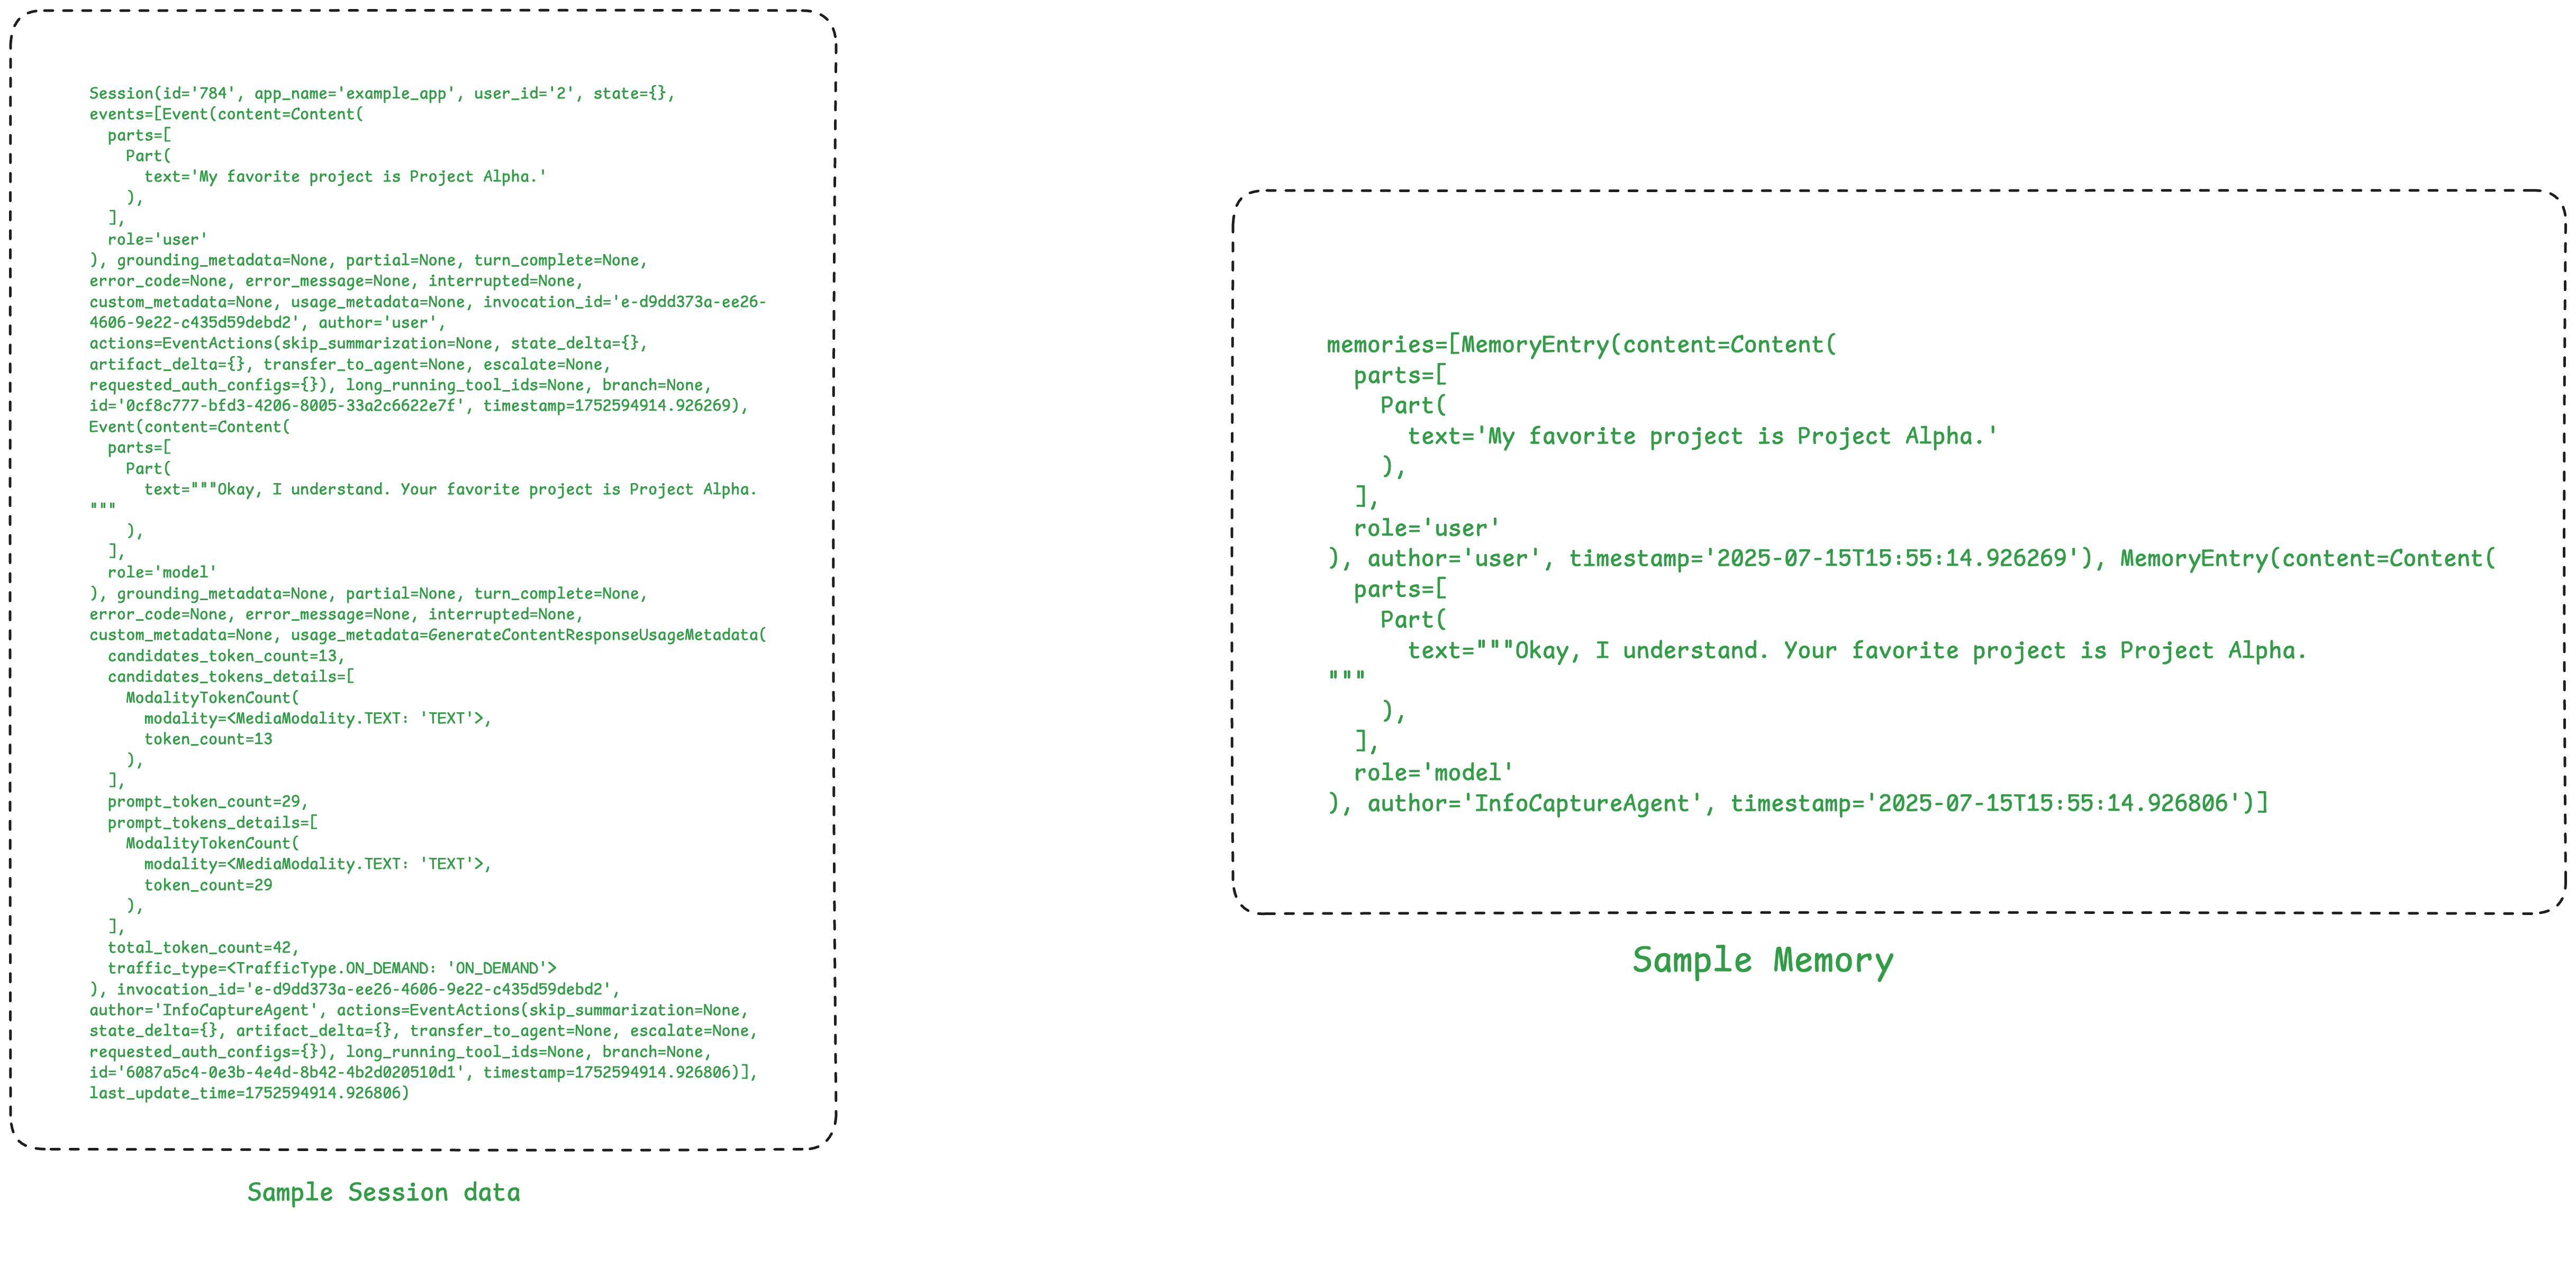

How Consolidation Works (Conceptual)

**The Pipeline**:
```
1. Raw Session Events
   ↓
2. LLM analyzes conversation
   ↓
3. Extracts key facts
   ↓
4. Stores concise memories
   ↓
5. Merges with existing memories (deduplication)
```
Example transformation:
```
Input:  "I'm allergic to peanuts. I can't eat anything with nuts."

Output: Memory {
  allergy: "peanuts, tree nuts"
  severity: "avoid completely"
}
```
Natural language → Structured, actionable data.


---


Next Steps for Memory Consolidation

`Key Point: Managed Memory Services handle consolidation automatically.`

You use the same API:
- `add_session_to_memory()` ← Same method
- `search_memory()` ← Same method

**The difference**: What happens behind the scenes.
- InMemoryMemoryService: Stores raw events
- VertexAiMemoryBankService: Intelligently consolidates before storing

Refer: <a href="https://docs.cloud.google.com/agent-builder/agent-engine/memory-bank/generate-memories">Vertex AI Memory bank: Memory Consolidation Guide</a>

# Resources

1. https://www.kaggle.com/code/kaggle5daysofai/day-3a-agent-sessions
2. https://www.kaggle.com/code/kaggle5daysofai/day-3b-agent-memory